## Exploratory Data Analysis & Feature Scaling

We've completed our Extraction, Transformation, Load steps in python scripts already so now we can do our Exploratory Data Analysis. We begin by loading in the data:

In [2]:
import sqlite3
import os
from pathlib import Path
import requests
import pandas as pd
from src.path_config import DB_PATH, RAW_DATA_DIR, PROCESSED_DATA_DIR
import matplotlib.pyplot as plt
import numpy as np

#Load in merged dataset from sqlite
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(
    "SELECT * FROM workforce_master",
    conn,
    dtype={'cbsa_code': str}
)
conn.close()
df.head()

,cbsa_code,metro_name,bachelors_or_higher_pct,employment,median_wage,rpp
0,10180,"Abilene, TX Metro Area",26.6,75070,44340,90.364
1,10420,"Akron, OH Metro Area",35.1,319560,48840,93.370
2,10500,"Albany, GA Metro Area",23.1,58390,43620,87.669
3,10540,"Albany, OR Metro Area",21.6,47260,49700,102.100
4,10580,"Albany-Schenectady-Troy, NY Metro Area",42.1,449410,58460,99.566


We can see that our data has been loaded into a dataframe successfully. Let's exlore the data further and do some basic checks.

In [3]:
print(df.info())
print(df.describe())
total_nulls = df.isna().sum().sum()
print("\nTotal null values: ", total_nulls)

<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cbsa_code                387 non-null    str    
 1   metro_name               387 non-null    str    
 2   bachelors_or_higher_pct  387 non-null    float64
 3   employment               387 non-null    int64  
 4   median_wage              387 non-null    int64  
 5   rpp                      387 non-null    float64
dtypes: float64(2), int64(2), str(2)
memory usage: 18.3 KB
None
       bachelors_or_higher_pct    employment   median_wage         rpp
count               387.000000  3.870000e+02    387.000000  387.000000
mean                 32.011886  3.448741e+05  48770.697674   94.885982
std                   9.020771  7.988766e+05   5990.482415    6.492754
min                  13.600000  1.882000e+04  35560.000000   83.597000
25%                  24.750000  5.889500e+04  45615.0000

Importantly we can see that our Core Based Statistical Area (CBSA) codes are strings, which ensures that if any codes begin with 0 they will not lose the digit by being converted to numeric data types automatically. The numbers are effectively our primary keys and won't have any numeric calculation done on them so it's fine fo them to stay strings. All other data types are as expected. We also see no null values which is a good sign.

We can also see what is high level data nationwide:
- The mean % of the population with a bachelor's degree or higher is 32%
- The mean size of employees in the workforce (employment) is 344,874 per CBSA
- Median wage is approximately $48k/yr

array([[<Axes: title={'center': 'bachelors_or_higher_pct'}>,
        <Axes: title={'center': 'employment'}>],
       [<Axes: title={'center': 'median_wage'}>,
        <Axes: title={'center': 'rpp'}>]], dtype=object)

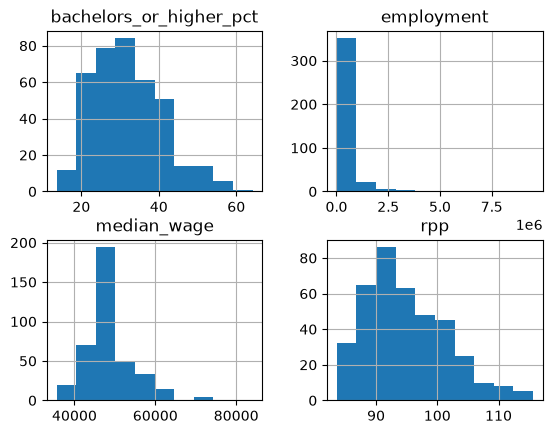

In [4]:
df.hist()

We can see that our data is decently distributed but definitely right-skewed, especially for employment. Let's take a closer look:

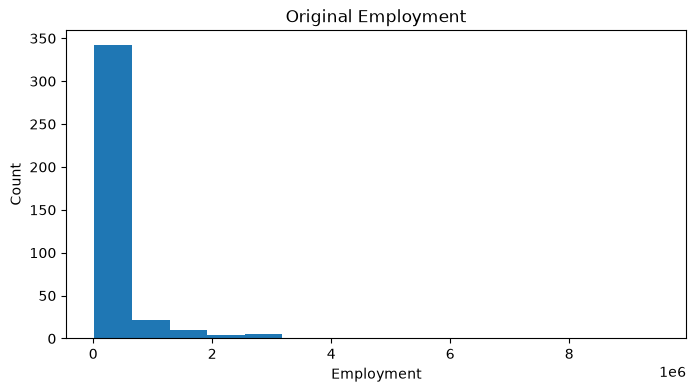

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(df["employment"], bins=15)
plt.title("Original Employment")
plt.xlabel("Employment")
plt.ylabel("Count")
plt.show()

## Feature Scaling 
This show us there are a tremendous amount of metro areas with a small amount of employees and a small amount of cities with that are orders of magnitude larger. We can see this in our data that the max value for employment is orders of magnitude than the minimum value. Intuitively this makes sense. There are a handful of mega-cities in the US but it is a large country with many, many smaller regions. A logarithmic scaler would likely help normalize these difference better than a standard scaler, so let's take a look how the same data looks after applying a log transformation:

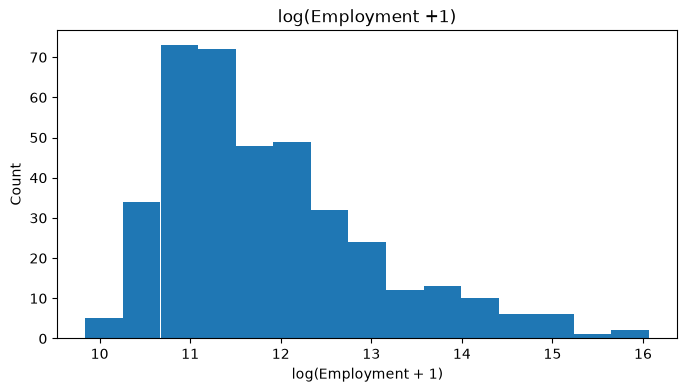

In [6]:
# Create log transformed version and compare to original
df["log_employment"] = np.log1p(df["employment"])
#Copy dataframe into a new dataframe for matrix transformations
X=df.copy()


plt.figure(figsize=(8, 4))
plt.hist(X["log_employment"], bins=15)
plt.title("log(Employment +1)")
plt.xlabel("log(Employment + 1)")
plt.ylabel("Count")
plt.show()

The data is still right-skewed but no long to such an extreme degree. This huge scale difference otherwise likely woudl over-influence our K-Means clustering algorithm we'll be using later. So we will use "log_employment" going forward. 

Next we will normalize our data using StandardScaler for a similar reason: we want our data values to contribute equally to distance values for clustering. 

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ["bachelors_or_higher_pct","log_employment","median_wage","rpp"]

#Drop original, untransformed employment data
X = X.drop(columns="employment")
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.head()

,cbsa_code,metro_name,bachelors_or_higher_pct,median_wage,rpp,log_employment
0,10180,"Abilene, TX Metro Area",-0.600713,-0.740580,-0.697368,-0.551747
1,10420,"Akron, OH Metro Area",0.342777,0.011584,-0.233791,0.717777
2,10500,"Albany, GA Metro Area",-0.989208,-0.860927,-1.112983,-0.771971
3,10540,"Albany, OR Metro Area",-1.155707,0.155331,1.112526,-0.957315
4,10580,"Albany-Schenectady-Troy, NY Metro Area",1.119768,1.619543,0.721739,1.016632


Now we check for duplicates and unique values:

In [8]:
print("Duplicate CBSA codes: ", X["cbsa_code"].duplicated().sum())
print("Duplicate Metro Names: ", X["metro_name"].duplicated().sum())
print("Rows:", len(X))
print("Unique CBSA codes: ", X["cbsa_code"].nunique())

Duplicate CBSA codes:  0
Duplicate Metro Names:  0
Rows: 387
Unique CBSA codes:  387


In [9]:
X[[
    "bachelors_or_higher_pct",
    "log_employment",
    "median_wage",
    "rpp"
]].corr()

,bachelors_or_higher_pct,log_employment,median_wage,rpp
bachelors_or_higher_pct,1.000000,0.465285,0.626985,0.497791
log_employment,0.465285,1.000000,0.425731,0.498774
median_wage,0.626985,0.425731,1.000000,0.709737
rpp,0.497791,0.498774,0.709737,1.000000


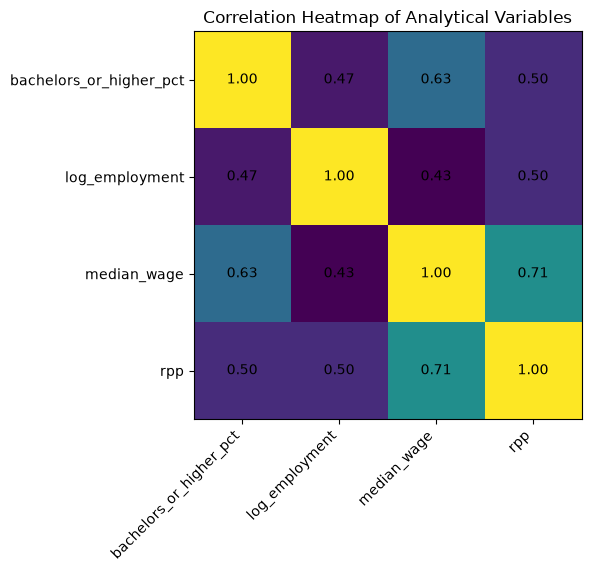

In [10]:
#Correlation Matrix

#Get numeric columns
columns = [
    "bachelors_or_higher_pct",
    "log_employment",
    "median_wage",
    "rpp"
]

corr_matrix = X[columns].corr()
fig, ax = plt.subplots(figsize=(6,6))
heatmap = ax.imshow(corr_matrix)

ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

# Display correlation values in each cell
for row in range(len(columns)):
    for col in range(len(columns)):
        ax.text(
            col,
            row,
            f"{corr_matrix.iloc[row, col]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Heatmap of Analytical Variables")
plt.tight_layout()
plt.show()

This looks good and we don't see extreme correlation overlap, which is a good sign that all are independent enough that they will provide value remaining in the model. We can see the strongest correlation is between median wage and regional price parity, which makes sense.

Now let's take a look at the top 5 cities ranked by educational attainment, just to get a preview of our data:

In [11]:
X.nlargest(5, "bachelors_or_higher_pct")

,cbsa_code,metro_name,bachelors_or_higher_pct,median_wage,rpp,log_employment
43,14500,"Boulder, CO Metro Area",3.572841,3.478224,1.590908,0.273059
163,27060,"Ithaca, NY Metro Area",2.973448,1.564385,1.300208,-0.944064
13,11460,"Ann Arbor, MI Metro Area",2.962348,1.104729,0.924381,0.389515
312,41940,"San Jose-Sunnyvale-Santa Clara, CA Metro Area",2.607152,5.896849,2.396076,1.828580
366,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV M...",2.485053,3.725602,2.158736,2.719388


*Fascinating.* Now let's move on to our clustering algorithm.

## Unsupervised Learning: K-Means Clustering
We'll be using the **K-Means clustering** algorithm and we'll need to do a little work tuning it. We begin by testing differnt amount of clusters (K) in the clustering algorithm and measuring results through Intertia (distance between a data point and the center of its cluster) and Silhouette (how similar a point is to its own cluster compared to other clusters). 

We start by testing 10 different K values and measuring the inertia score. *Lower* inertia scores suggest compact clusters:

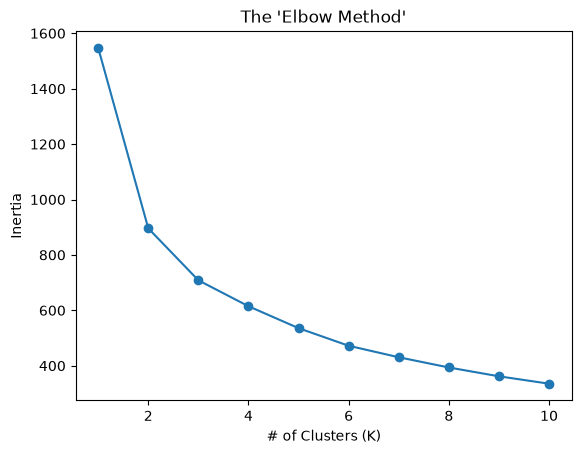

In [12]:
from sklearn.cluster import KMeans

#Drop non-numeric value from dataframe before clustering or model will break
X_numeric = X[["bachelors_or_higher_pct","log_employment",'rpp','median_wage']].copy()

#Create array to hold intertia values (sum of squared distances inside clusters)
inertias = []

#Test every value from 1-10
K = range(1,11)
for i in K:
    model = KMeans(n_clusters=i, random_state=67, n_init=10)
    model.fit(X_numeric)
    inertias.append(model.inertia_)

#Plot results to look for "elbow" where improvment slows down
plt.plot(K, inertias, marker="o")
plt.xlabel("# of Clusters (K)")
plt.ylabel("Inertia")
plt.title("The 'Elbow Method'")
plt.show()

We see a sharp drop from 1 to 2 clusters, and diminishing returns thereafter. I would say K=3 or K=4 would be better as there are diminishing returns beyond. 

However we still need to test for silhouette scores for each K value. *Higher* inertia scores suggest stronger clustering by having more separation between clusters:

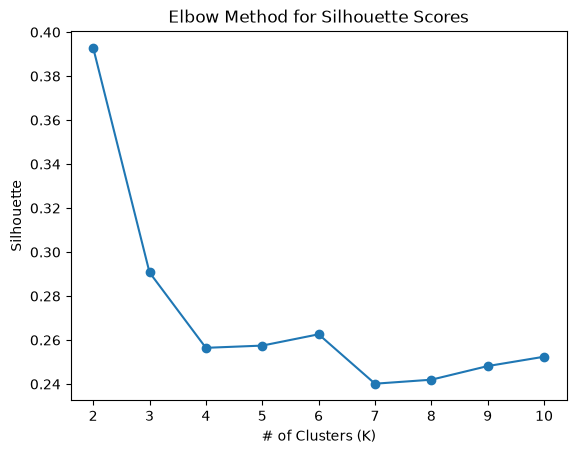

In [13]:
from sklearn.metrics import silhouette_score

#Create array to store scores
scores = []

#Test 2-10, need min 2 clusters to measure difference between clusters
for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=67, n_init=10)
    labels = model.fit_predict(X_numeric)
    score = silhouette_score(X_numeric, labels)
    scores.append(score)

plt.plot(range(2,11), scores, marker="o")
plt.xlabel("# of Clusters (K)")
plt.ylabel("Silhouette")
plt.title("Elbow Method for Silhouette Scores")
plt.show()

We see that K=6 is a small uptick in silhouette score. This is interesting. K=2 has the strongest separation, but is also the least granular solution and would likely limit our ability to make meaningful analysis of the clusters. 

While a 2 cluster solution has the best silhouette score it doesn't offer much segmentation for market analysis. Additional clusters offer marginal reductions in inertia but mostly lower silhouette scores. After testing with K=3 it offers good balance of intertia and silhouette scores, and provides distinct market profiles with highly interpretable clusters:

In [14]:
#Perform KMeans clustering on standardized numeric features only
kmeans = KMeans(n_clusters=3, random_state=67, n_init=10)
labels = kmeans.fit_predict(X_numeric)

#Assign cluster assignments back to each metro in the original dataframe 
df["cluster"] = labels

#Review centroids of each cluster to see mean feture values of each metro in each group
centers = pd.DataFrame(kmeans.cluster_centers_,columns=X_numeric.columns)
centers

,bachelors_or_higher_pct,log_employment,rpp,median_wage
0,0.387176,0.441307,0.164750,0.022727
1,-0.729256,-0.634109,-0.645002,-0.569685
2,1.304942,0.905459,1.543409,1.632146


These are relative values in standard deviations from the mean in each category. A few preliminary profiles emerge:
- Cluster 0: Midsize education intensive
- Cluster 1: Small lower cost
- Cluster 2: Large highly developed

These are simple descriptions for hundreds of cities so there will be variance within each cluster, but it's helpful to have a simple shorthand we can reference when doing our analysis. It is also worth reminding the reader that none of these are intended to be value judgements. There are many features not being considered here like crime rates, cuisine ratings, life expectancy, or acres of wilderness that would affect anyone's personal preferences. Those considerations are valuable but outside the scope of this project.

In [15]:
print("Total counts of metros in each cluster: ")
df["cluster"].value_counts().sort_index()

Total counts of metros in each cluster: 


cluster
0    138
1    186
2     63
Name: count, dtype: int64

A good amount of metros in each cluster. We can also see the largest amount of metros are in cluster 1, the smaller, more affordable metros. The fewest are in cluster 3, the largest, most expensive and educated metros.

## Principal Component Analysis
We can expand our understanding of the data further by using Principal Component Analysis. 3 Principal Components (PCs) would be needed to explain 90%+ of the variance in the data:

In [16]:
from sklearn.decomposition import PCA

#Determine amount of principal components needed to capture 90% of variance
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_numeric)
print("PCs needed for 90% variance: ", X_pca.shape[1])
print("Total variance captured by", X_pca.shape[1], "PCs:", pca.explained_variance_ratio_.sum())

PCs needed for 90% variance:  3
Total variance captured by 3 PCs: 0.9380436781737456


Let's examine the loadings for each principal component:

In [17]:
#Create new dataframe of Principal Components
loadings = pd.DataFrame(
    pca.components_,
    columns=X_numeric.columns,
    index=["PC1","PC2","PC3"]
)
loadings["variance"] = pca.explained_variance_ratio_

print(loadings)

     bachelors_or_higher_pct  log_employment       rpp  median_wage  variance
PC1                 0.494254        0.442859  0.522157     0.535668  0.655579
PC2                -0.130658        0.876205 -0.181515    -0.426903  0.154967
PC3                 0.795171       -0.056906 -0.594046    -0.107585  0.127497


PC1 shows positive spread in education (bachelors or higher %), workforce size (log of employment), and RPP. This is by far our largest by variance and accounts for about 2/3 of the variance in our data. We could interpret this as "overall metropolitan development" as all three features have similar positive loadings and rise together. Most of the variance in the data can be explained by this. 

PC2 distinguishes between employment size and cost. High PC2 indicates large workforce size but not necessarily high cost of education. We could describe this as employment independent of cost. 

PC3 is dominated by education and has RPP moving in the opposite direction. High PC3 indicates relatively high education and lower cost. We could describe this as education relative to cost of living. 

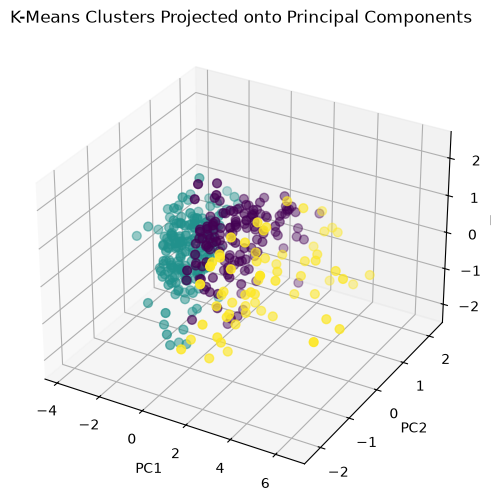

In [18]:
#Plot K-Means clusters on Principal Components in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=labels,
    s=40
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-Means Clusters Projected onto Principal Components")
plt.show()

If we color code our metros by cluster and project them onto the three dimensions of our PCA we can see more patterns emerge. We see a sort of cone shape where clusters lower on PC1 are more tightly clustered than those higher in PC1. As PC1 increases we see increased spread in PC2 and to a lesser extent in PC3. While PC1 is overall responsible for the most variance, the variance captured by PC2 and PC3 are almost equal. It appears "more developed" metro areas high in PC1 exhibit greater diversity in combinations of educational attainment, workforce size, median wages, and cost of living. Metro areas with lower PC1 scores appear more homogenous in these measured features.

In [19]:
#Assign names to cluster labels
cluster_names = {
    0: "Midsize affordable",
    1: "Small inexpensive",
    2: "Largest expensive"
}

df["cluster_label"] = df["cluster"].map(cluster_names)

#Print sample of metros from each cluster
for label in df.cluster_label.unique():
    print(f'\n{label}')
    print((df[df['cluster_label']==label].sample(n=3, random_state=67)
        [["metro_name","bachelors_or_higher_pct","employment","rpp"]]))


Small inexpensive
                       metro_name  bachelors_or_higher_pct  employment     rpp
323      Sheboygan, WI Metro Area                     27.5       60630  94.014
301  St. Joseph, MO-KS Metro Area                     23.8       54390  86.382
263     Paducah, KY-IL Metro Area                     24.7       50270  86.084

Midsize affordable
                                       metro_name  bachelors_or_higher_pct  \
7    Allentown-Bethlehem-Easton, PA-NJ Metro Area                     33.5   
17            Athens-Clarke County, GA Metro Area                     43.2   
264  Palm Bay-Melbourne-Titusville, FL Metro Area                     34.2   

     employment      rpp  
7        377180   99.968  
17        95800   93.343  
264      245170  100.005  

Largest expensive
                                        metro_name  bachelors_or_higher_pct  \
275         Portland-South Portland, ME Metro Area                     45.9   
312  San Jose-Sunnyvale-Santa Clara, CA Metro A

These random samples from each cluster fit reasonably well with their descriptions. Let's now move onto our hypothesis test.

## Hypothesis Test
**Null hypothesis (H₀):** Regional price parity does not significantly improve the explanation of metropolitan wage variation beyond educational attainment and workforce size.

**Alternative hypothesis (H₀):** Regional price parity significantly improves the explanation of metropolitan wage variation beyond educational attainment and workforce size.

To evaluate this hypothesis we'll use **Multiple Linear Regression**.

In [20]:
import statsmodels.api as sm

#Set dependent variables
X1 = df[["bachelors_or_higher_pct", "log_employment"]]
X1 = sm.add_constant(X1)

#Set independent variable
y = df["median_wage"]

#Run regression model
model1 = sm.OLS(y, X1).fit()
print("Reduced Model:")
print(model1.summary())


Reduced Model:
                            OLS Regression Results                            
Dep. Variable:            median_wage   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     136.8
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.40e-45
Time:                        03:19:03   Log-Likelihood:                -3810.6
No. Observations:                 387   AIC:                             7627.
Df Residuals:                     384   BIC:                             7639.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const      

In [21]:
#Set dependent variables
X2 = df[["bachelors_or_higher_pct", "log_employment", "rpp"]]
X2 = sm.add_constant(X2)

#Run regression model, reusing dependent variable
model2 = sm.OLS(y, X2).fit()
print("Full Model:")
print(model2.summary())

Full Model:
                            OLS Regression Results                            
Dep. Variable:            median_wage   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     194.2
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.49e-76
Time:                        03:19:03   Log-Likelihood:                -3735.8
No. Observations:                 387   AIC:                             7480.
Df Residuals:                     383   BIC:                             7495.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const         

We see a warning for multicollinearity so we can test this by measuring Variance Inflation Factor. A score between 1 and 5 is acceptable, lower values are better.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Variable"] = X2.columns
vif["VIF"] = [
    variance_inflation_factor(X2.values, i)
    for i in range(X2.shape[1])
]

print(vif)

                  Variable         VIF
0                    const  258.864795
1  bachelors_or_higher_pct    1.450282
2           log_employment    1.452174
3                      rpp    1.512611


VIF scores for all three variables are low so we can proceed.

We will proceed with our Nested F-test to measure if the additional amount of explained variance in our second model from adding RPP is stastitically significant. This is how we will test our hypothesis.

In [35]:
#Run Nested F-test w/ Statsmodels, compare reduced model1 with full model2
f_stat, p_value, df_diff = model2.compare_f_test(model1)

#Predetermined significance level
alpha = 0.05

#Print results of Nested F-test
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Alpha: {alpha}")
print(f"Difference in degrees of freedom: {int(df_diff)}\n")

#Evaluate hypothesis and print out
if p_value < alpha:
    print("We reject the null hypothesis!")
    print("Adding RPP significantly improves the regression model.")
else:
    print("We fail to reject the null hypothesis!")
    print("Adding RPP does not significantly improve the regression model.")

F-statistic: 180.92
P-value: 4.78e-34
Alpha: 0.05
Difference in degrees of freedom: 1

We reject the null hypothesis!
Adding RPP significantly improves the regression model.


We have now completed our hypothesis test and rejected the null hypothesis. We can now confirm that adding RPP improves the model at a statistically significant level. 

Next we will evaluate the residual vales in predicted vs observed median wages values from the model.

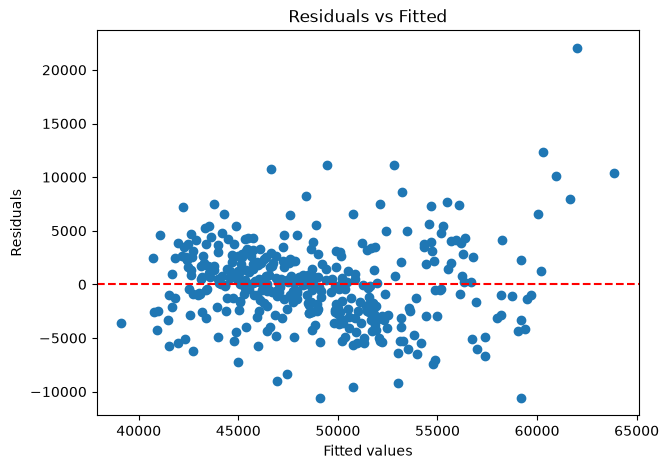

In [24]:
#Plot scatterplot of residuals in predicted vs observed median wages.
plt.figure(figsize=(7,5))
plt.scatter(model2.fittedvalues, model2.resid)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

We can see the residuals are higher as we go higher in median wages. This is in line with our previous analysis that there appears to be more variance in more economically developed or expensive metros.

Next we will evaluate if the values of the residuals are roughly normally distributed. Ideally they would be, because if our residual values are skewed one way or the other the model is likely to be consistently under or over estimating.

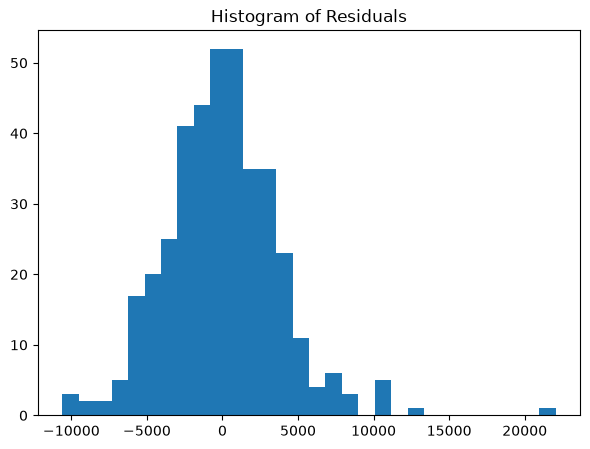

In [25]:
#Plot histogram of residual values
plt.figure(figsize=(7,5))
plt.hist(model2.resid, bins=30)

plt.title("Histogram of Residuals")
plt.show()

We can see the values are roughly normally distributred over 0, which is a good sign. We again see a few outliers on the higher end, but that is consistent with our previous analysis and only a modest amount. 

We will visualize this another way, using a Q-Q plot. This is an easy to implement test that will give us another easy to interpret measure of the model's performance with regard to observed versus predicted wages.

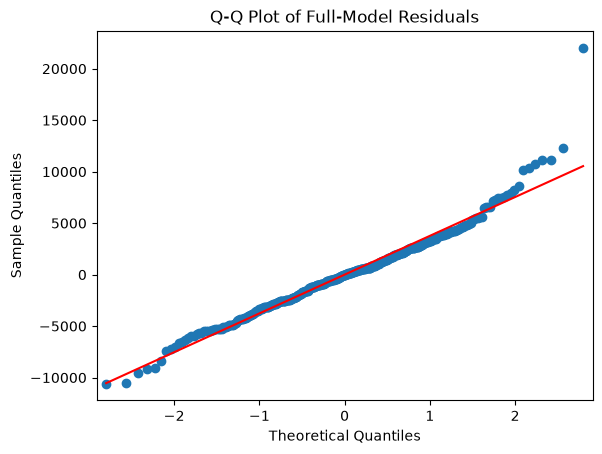

In [26]:
#Plot model residuals using Q-Q plot
sm.qqplot(model2.resid, line="s")

plt.title("Q-Q Plot of Full-Model Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

Again, a small amount of very high variance at the highest end of wages, but we can also see some interesting residuals below the line of prediction at the very lowest end. This suggests there are some metros with wages that are below where we would expect them to be, relative to the features of their workforce. This is valuable information for our research question. 

Finally, we will use a plot to measure Cook's Distance. Cook's Distance can identify highly influential metros that could disproportionately affect the model's estimated coefficients.

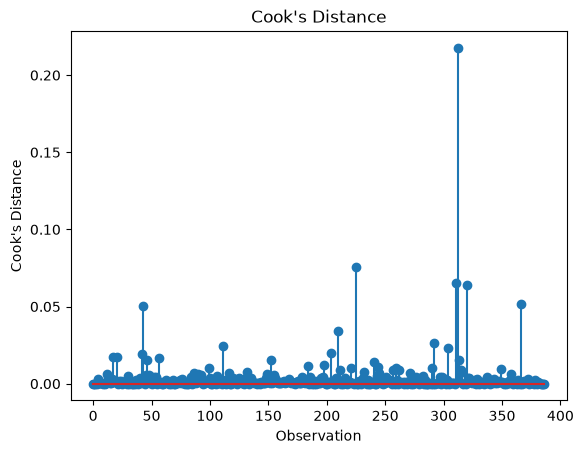

In [27]:
#Plot Cook's distance

#Use Statsmodels method to calculate influence
influence = model2.get_influence()

#Statsmodels calculates CD from the measured influence
cooks = influence.cooks_distance[0]

plt.figure()
plt.stem(range(len(cooks)), cooks)

plt.title("Cook's Distance")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")

plt.show()

We see no values over 1, which would be a big warning. We see a handful of metros exerting above average influence, but most are near 0 which is what we'd want to see. We are doing this to make sure we don't have too many outliers adding undue influence to the model. 

We can identify which metros have the highest distance. San Jose-Sunnyvale-Santa Clara is the highest value with a sharp drop below:

In [28]:
influence = model2.get_influence()
cooks_d = influence.cooks_distance[0]

top = pd.DataFrame({
    "Metro": df["metro_name"],
    "Cook's Distance": cooks_d
})

top.sort_values("Cook's Distance", ascending=False).head(5)

,Metro,Cook's Distance
312,"San Jose-Sunnyvale-Santa Clara, CA Metro Area",0.217807
225,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",0.075766
311,"San Francisco-Oakland-Fremont, CA Metro Area",0.065125
320,"Seattle-Tacoma-Bellevue, WA Metro Area",0.063939
366,"Washington-Arlington-Alexandria, DC-VA-MD-WV M...",0.051386


With strong confidence in our model we can go further towards addressing the research question by identifying which metropolitan areas have the biggest differences in residual values, either above or below expected. Nationally this would only be moderately interesting. We can improve the value of this analysis by narrowing our search.

Our K-Means clustering resulted in 3 groups, with cluster 0 having above average educational attainment and workforce size, but with average wages. These are interesting as they are already likely to be metros which reasonably large and reasonably educated workforces. By picking which metros in this cluster have the greatest negative residuals we can see which have wages lower than what the model would predict, relative to their workforce features. These are the "value" labor markets that an organization might want to investigate further for recruiting good talent at affordable cost.

In [29]:
#Create new dataframe with raw data plus residuals
analysis_df = df.copy()

analysis_df["predicted_wage"] = model2.predict(X2)
analysis_df["residual"] = model2.resid

#Select cluster of choice for analysis
cluster_choice = 0
cluster_selection = analysis_df[analysis_df["cluster"] == cluster_choice].copy()

#Filter results to only variables of interest
cluster_selection = cluster_selection[
    [
        "metro_name",
        "median_wage",
        "predicted_wage",
        "residual",
        "bachelors_or_higher_pct",
        "employment",
        "rpp"
    ]
].copy()

#Round residuals for easy reading
cluster_selection["residual"] = (cluster_selection["residual"].round(0).astype(int))
cluster_selection["predicted_wage"] = (cluster_selection["predicted_wage"].round(0).astype(int))

#Top 10 metros with wages furthest below predictions
print(f"Top 10 Metros with wages furthest below predictions in Cluster {cluster_choice}:")
cluster_selection.sort_values("residual").head(10)

Top 10 Metros with wages furthest below predictions in Cluster 0:


,metro_name,median_wage,predicted_wage,residual,bachelors_or_higher_pct,employment,rpp
17,"Athens-Clarke County, GA Metro Area",41220,50760,-9540,43.2,95800,93.343
152,"Hilton Head Island-Bluffton-Port Royal, SC Met...",43850,53040,-9190,43.1,81920,98.017
304,"Salinas, CA Metro Area",47380,54780,-7400,28.2,186430,109.042
245,"Naples-Marco Island, FL Metro Area",47800,54862,-7062,40.3,173880,103.200
251,"North Port-Bradenton-Sarasota, FL Metro Area",47440,53953,-6513,38.3,339940,102.417
259,"Orlando-Kissimmee-Sanford, FL Metro Area",46630,52994,-6364,36.7,1411730,101.418
116,"Flagstaff, AZ Metro Area",47500,53503,-6003,40.3,66610,100.325
300,"St. George, UT Metro Area",45140,50768,-5628,35.2,90500,97.321
378,"Wilmington, NC Metro Area",45800,51308,-5508,39.4,191280,96.422
321,"Sebastian-Vero Beach-West Vero Corridor, FL Me...",45480,50936,-5456,33.8,57620,98.308


We could easily change the cluster selection to investigate other types of metropolitan areas, but Cluster 0 would make for a good choice for many organizations. Metros in Cluster 0 all have above average education levels and workforce size at average levels, which could already potentially be good value staff to hire. By measuring for negative residuals in this group we take this analysis even further by identifying which metros within Cluster 0 have even lower wages relative to their above average features in education and workforce size. This should not be anyone's final analysis but it does represent a very valuable starting point for further investigation. 